In [140]:

%load_ext autoreload
%autoreload 2

from jaxopt import ProjectedGradient
from jaxopt.projection import projection_simplex

import jax
# jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

from jax import jit
from jax.scipy.linalg import expm

from qdots_qll.models.single_dot_weak_coupling_GAME import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
m = SingleDotWeakCouplingGAME()

In [3]:
true_parameters

Array([ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482], dtype=float32)

In [4]:
t = 25.4

In [5]:
m.likelihood_particle(true_parameters, t).shape

(4, 3, 2)

In [6]:
key = jax.random.PRNGKey(seed=1)

In [7]:
key, subkey = jax.random.split(key)
outcome = m.generate_data(subkey, true_parameters, t, 0, 2)

In [8]:
lkl = m.likelihood_particle(true_parameters, t)

In [9]:
lkl[0, 2, 0]

Array(0.37952685, dtype=float32)

In [ ]:
# from qdots_qll.run import RunConditionalMeasurementsInitialStates
# RunConditionalMeasurementsInitialStates()


In [10]:
def est_par(pars, weights): return (weights[:, None] * pars).sum(0) / weights.sum(0)


def det_FIM(m, particle, t, dist_initial_states, dist_measurements):
    fim = m.fim(particle, t, dist_initial_states, dist_measurements)
    return jnp.linalg.det(fim)


def regularized_det_FIM(m, particle, t, dist_initial_states, dist_measurements):
    fim = m.fim(particle, t, dist_initial_states, dist_measurements)
    penalty = jnp.log(dist_initial_states) + jnp.log(dist_initial_state)
    return jnp.linalg.det(fim) + penalty.sum()


check_nan = jax.jit(lambda a: jax.lax.cond(jnp.isnan(a), lambda a: 0.0, lambda a: a, a))


In [11]:
from qdots_qll.resamplers import LWResampler

resampler = LWResampler(a=0.95)


In [16]:
import equinox as eqx
import optax

In [17]:
class MaxDetFimExpDesign(eqx.Module):
    t_min: float
    t_max: float
    sgd_iter: int
    lr: float

    def __init__(self, t_min, t_max, sgd_iter, lr, *args, **kwargs) -> None:
        self.t_min = t_min
        self.t_max = t_max
        self.sgd_iter = sgd_iter
        self.lr = lr

    # @jit
    def utility_function(self, model, t, **kwargs):
        fim = model.fim(t=t, **kwargs)
        return jnp.linalg.det(fim)

    # @jit
    def optimize_utility_function(
            self, model, t, **kwargs
    ):
        util_fun = lambda t: -1 * jnp.linalg.det(model.fim(t=t, **kwargs))

        grad_f = jax.grad(util_fun, 0)

        # def grad_f(t):
        #     return -jax.grad(self.utility_function, 2)(
        #          model=model, t = t,  **kwargs
        #     )
        # 
        def f_for_scan(carry, x):
            params, opt_state = carry
            grad = grad_f(params)
            updates, opt_state = solver.update(grad, opt_state, params)
            params = optax.apply_updates(params, updates)
            return [params, opt_state], params

        solver = optax.adam(learning_rate=self.lr)
        params = t
        opt_state = solver.init(params)

        re = jax.lax.scan(f_for_scan, [params, opt_state], None, length=3)
        return re[0][0]

    # 
    @jit
    def generate_time(
            self,
            key,
            particles_locations,
            weights,
            model,
            **kwargs
    ):
        est_particle = est_mean(particles_locations, weights)

        util_fun = lambda t: 1 * jnp.linalg.det(model.fim(t=t, particle=est_particle, **kwargs))

        no_candidates = 10

        key, subkey = jax.random.split(key)

        times_candidates = jax.random.uniform(
            subkey,
            shape=(no_candidates,),
            minval=self.t_min,
            maxval=self.t_max,
        )

        times_optimized = jax.vmap(
            lambda t: self.optimize_utility_function(
                model=model, t=t, particle=est_particle, **kwargs
            )
        )(times_candidates)

        utilities = jax.vmap(
            lambda t: (
                util_fun(t)
            ),
        )(times_optimized)
        return times_optimized[jnp.argmax(utilities)]

In [18]:
no_initial_states = 4
no_measurement_basis = 3
dist_initial_state = jnp.ones(no_initial_states) / no_initial_states
dist_measurement_basis = jnp.ones(no_measurement_basis) / no_measurement_basis

expdesign = MaxDetFimExpDesign(0.1, 50., 10, 0.5)
expdesign.utility_function(model=m, t=t, particle=true_parameters, prob_initial_state=dist_initial_state,
                           prob_measurement_basis=dist_measurement_basis)

Array(0.04468621, dtype=float32)

In [ ]:
t

In [19]:
expdesign.optimize_utility_function(model=m, t=t, particle=true_parameters, prob_initial_state=dist_initial_state,
                                    prob_measurement_basis=dist_measurement_basis)

Array(23.91665, dtype=float32)

In [ ]:
expdesign.generate_time(subkey, (true_parameters[None, :] * np.ones(100)[:, None]), weights / weights.sum(), model=m,
                        prob_initial_state=dist_initial_state, prob_measurement_basis=dist_measurement_basis)

In [ ]:

times = jnp.linspace(0, 50, 1000)

detfimtimes = jax.vmap(lambda t: jnp.linalg.det(m.fim(true_parameters, t, dist_initial_state, dist_measurement_basis)))(
    times)

# new_detfimtimes = jax.vmap(
#     lambda t: jnp.linalg.det(m.fim(true_parameters, t, new_pars1, new_pars2)))(times)
best_time = expdesign.generate_time(subkey, (true_parameters[None, :] * np.ones(100)[:, None]), weights / weights.sum(),
                                    model=m, prob_initial_state=dist_initial_state,
                                    prob_measurement_basis=dist_measurement_basis)
plt.plot(times, detfimtimes, label="unoptimized")
plt.axvline(best_time)
# plt.plot(times, new_detfimtimes, label='optimized')
plt.legend()

In [20]:
def est_mean(particles_locations, weights):
    return jnp.einsum('ij, i-> j', particles_locations, weights)


@jit
def est_cov(particles_locations, weights):
    return jnp.einsum(
        "i, im, ik -> mk", weights, particles_locations, particles_locations
    ) - jnp.einsum(
        "i, ij, m, mk -> jk",
        weights,
        particles_locations,
        weights,
        particles_locations,
    )


In [194]:
def step_adaptive(key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, previous_time):
    key, subkey = jax.random.split(key)
    # t = jax.random.uniform(subkey, minval=0.1, maxval=45.)
    t = expdesign.generate_time(subkey, particles_locations, weights, model=m, prob_initial_state=dist_initial_state,
                                prob_measurement_basis=dist_measurement_basis)
    estimated_parameters = est_par(particles_locations, weights)

    # grad_p_initial_state = jax.grad(det_FIM, 3)(m, estimated_parameters, t, dist_initial_state,
    #                                             dist_measurement_basis)
    # print(grad_p_initial_state)

    # grad_p_measurement_basis = jax.grad(det_FIM, 4)(m, estimated_parameters, t, dist_initial_state,
    #                                                 dist_measurement_basis)

    # grad_p_initial_state = grad_p_initial_state + jnp.abs(jnp.min(grad_p_initial_state))
    # dist_initial_state = dist_initial_state + 0.01 * grad_p_initial_state / grad_p_initial_state.sum()
    # # dist_initial_state = dist_initial_state + jnp.abs(jnp.min(dist_initial_state))
    # dist_initial_state = dist_initial_state / dist_initial_state.sum()
    # 
    # grad_p_measurement_basis = grad_p_measurement_basis + jnp.abs(jnp.min(grad_p_measurement_basis))

    # dist_measurement_basis = dist_measurement_basis + 0.01 * grad_p_measurement_basis / grad_p_measurement_basis.sum()
    # 
    # # dist_measurement_basis = dist_measurement_basis + jnp.abs(jnp.min(dist_measurement_basis))
    # dist_measurement_basis = dist_measurement_basis / dist_measurement_basis.sum()

    key, subkey = jax.random.split(key)

    chosen_initial_state = jax.random.choice(subkey, jnp.arange(no_initial_states), p=dist_initial_state)
    key, subkey = jax.random.split(key)

    chosen_basis = jax.random.choice(subkey, jnp.arange(no_measurement_basis), p=dist_measurement_basis)
    key, subkey = jax.random.split(key)

    outcome = m.generate_data(subkey, true_parameters, t, chosen_initial_state, chosen_basis)

    lkl_particles = jax.vmap(lambda particle: check_nan(m.likelihood_particle(particle, t)[*outcome]))(
        particles_locations)

    # lkl_particles = jax.vmap(lambda a: check_nan(a))(lkl_particles)

    lkl_particles = lkl_particles * dist_initial_state[chosen_initial_state] * dist_measurement_basis[chosen_basis]

    weights = weights * lkl_particles
    weights = weights / weights.sum()

    def true_fun(key, particles_locations, weights):
        return_resampler = resampler.resample(key, particles_locations, weights)
        key = return_resampler["key"]
        weights = return_resampler["weights"]
        particles_locations = return_resampler["particles_locations"]
        return key, particles_locations, weights

    def false_fun(key, particles_locations, weights):
        return key, particles_locations, weights

    key, particles_locations, weights = jax.lax.cond(1 / ((weights ** 2).sum()) <= 1 * no_particles / 2, true_fun,
                                                     false_fun, *[key, particles_locations, weights])

    return key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, t


def step(key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, previous_time):
    key, subkey = jax.random.split(key)
    t = jax.random.uniform(subkey, minval=0.1, maxval=45.)

    key, subkey = jax.random.split(key)

    chosen_initial_state = jax.random.choice(subkey, jnp.arange(no_initial_states), p=dist_initial_state)
    key, subkey = jax.random.split(key)

    chosen_basis = jax.random.choice(subkey, jnp.arange(no_measurement_basis), p=dist_measurement_basis)
    key, subkey = jax.random.split(key)

    outcome = m.generate_data(subkey, true_parameters, t, chosen_initial_state, chosen_basis)

    lkl_particles = jax.vmap(lambda particle: check_nan(m.likelihood_particle(particle, t)[*outcome]))(
        particles_locations)

    # lkl_particles = jax.vmap(lambda a: check_nan(a))(lkl_particles)

    lkl_particles = lkl_particles * dist_initial_state[chosen_initial_state] * dist_measurement_basis[chosen_basis]

    weights = weights * lkl_particles
    weights = weights / weights.sum()

    def true_fun(key, particles_locations, weights):
        return_resampler = resampler.resample(key, particles_locations, weights)
        key = return_resampler["key"]
        weights = return_resampler["weights"]
        particles_locations = return_resampler["particles_locations"]
        return key, particles_locations, weights

    def false_fun(key, particles_locations, weights):
        return key, particles_locations, weights

    key, particles_locations, weights = jax.lax.cond(1 / ((weights ** 2).sum()) <= 1 * no_particles / 2, true_fun,
                                                     false_fun, *[key, particles_locations, weights])

    return key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, t


def step_fully_adaptive(key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m,
                        previous_time):
    key, subkey = jax.random.split(key)
    # t = jax.random.uniform(subkey, minval=0.1, maxval=45.)
    t = expdesign.generate_time(subkey, particles_locations, weights, model=m, prob_initial_state=dist_initial_state,
                                prob_measurement_basis=dist_measurement_basis)
    estimated_parameters = est_par(particles_locations, weights)

    # grad_p_initial_state = jax.grad(det_FIM, 3)(m, estimated_parameters, t, dist_initial_state,
    #                                             dist_measurement_basis)
    # print(grad_p_initial_state)

    # grad_p_measurement_basis = jax.grad(det_FIM, 4)(m, estimated_parameters, t, dist_initial_state,
    #                                                 dist_measurement_basis)

    # grad_p_initial_state = grad_p_initial_state + jnp.abs(jnp.min(grad_p_initial_state))
    # dist_initial_state = dist_initial_state + 0.01 * grad_p_initial_state / grad_p_initial_state.sum()
    # # dist_initial_state = dist_initial_state + jnp.abs(jnp.min(dist_initial_state))
    # dist_initial_state = dist_initial_state / dist_initial_state.sum()
    # 
    # grad_p_measurement_basis = grad_p_measurement_basis + jnp.abs(jnp.min(grad_p_measurement_basis))

    # dist_measurement_basis = dist_measurement_basis + 0.01 * grad_p_measurement_basis / grad_p_measurement_basis.sum()
    # 
    # # dist_measurement_basis = dist_measurement_basis + jnp.abs(jnp.min(dist_measurement_basis))
    # dist_measurement_basis = dist_measurement_basis / dist_measurement_basis.sum()
    def update_distributions(model, **kwargs):
        loss_f_initial_state = lambda p_state, p_basis: -1 * jnp.linalg.det(
            model.fim(prob_initial_state=p_state, prob_measurement_basis=p_basis, **kwargs))
        loss_f_measurement_basis = lambda p_basis, p_state: -1 * jnp.linalg.det(
            model.fim(prob_initial_state=p_state, prob_measurement_basis=p_basis, **kwargs))

        pg1 = ProjectedGradient(fun=loss_f_initial_state, projection=projection_simplex, verbose=False, stepsize=0.2)

        pg2 = ProjectedGradient(fun=loss_f_measurement_basis, projection=projection_simplex, verbose=False,
                                stepsize=0.2)

        pg1_init_state = pg1.init_state(init_params=dist_initial_state, p_basis=dist_measurement_basis)

        pg2_init_state = pg2.init_state(init_params=dist_measurement_basis, p_state=dist_initial_state)

        new_pars1 = dist_initial_state
        new_pars2 = dist_measurement_basis

        new_state1 = pg1_init_state
        new_state2 = pg2_init_state

        new_pars1, new_state1 = pg1.update(new_pars1, state=new_state1, p_basis=new_pars2)

        new_pars2, new_state2 = pg2.update(new_pars2, state=new_state2, p_state=new_pars1)
        return new_pars1, new_pars2

    # 
    dist_initial_state, dist_measurement_basis = update_distributions(model=m, dist_initial_state=dist_initial_state,
                                                                      dist_measurement_basis=dist_measurement_basis,
                                                                      t=t, particle=estimated_parameters)

    key, subkey = jax.random.split(key)

    chosen_initial_state = jax.random.choice(subkey, jnp.arange(no_initial_states), p=dist_initial_state)
    key, subkey = jax.random.split(key)

    chosen_basis = jax.random.choice(subkey, jnp.arange(no_measurement_basis), p=dist_measurement_basis)
    key, subkey = jax.random.split(key)

    outcome = m.generate_data(subkey, true_parameters, t, chosen_initial_state, chosen_basis)

    lkl_particles = jax.vmap(lambda particle: check_nan(m.likelihood_particle(particle, t)[*outcome]))(
        particles_locations)

    # lkl_particles = jax.vmap(lambda a: check_nan(a))(lkl_particles)

    lkl_particles = lkl_particles * dist_initial_state[chosen_initial_state] * dist_measurement_basis[chosen_basis]

    weights = weights * lkl_particles
    weights = weights / weights.sum()

    def true_fun(key, particles_locations, weights):
        return_resampler = resampler.resample(key, particles_locations, weights)
        key = return_resampler["key"]
        weights = return_resampler["weights"]
        particles_locations = return_resampler["particles_locations"]
        return key, particles_locations, weights

    def false_fun(key, particles_locations, weights):
        return key, particles_locations, weights

    key, particles_locations, weights = jax.lax.cond(1 / ((weights ** 2).sum()) <= 1 * no_particles / 2, true_fun,
                                                     false_fun, *[key, particles_locations, weights])

    return key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, t



In [195]:
# init = [key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m] 
# f must output carry, y , 
@jax.jit
def f_for_scan_non_adaptive(carry, _):
    key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, time = step(*carry)
    covariance = est_cov(particles_locations, weights)
    # cumulative = cumulative + time
    carry = [key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, time]
    return carry, [covariance, time]


@jax.jit
def f_for_scan_adaptive(carry, _):
    key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, time = step_adaptive(*carry)
    covariance = est_cov(particles_locations, weights)
    carry = [key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, time]
    return carry, [covariance, time]


@jax.jit
def f_for_scan_fully_adaptive(carry, _):
    key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, time = step_fully_adaptive(*carry)
    covariance = est_cov(particles_locations, weights)
    carry = [key, particles_locations, weights, dist_initial_state, dist_measurement_basis, m, time]
    return carry, [covariance, time]

In [196]:
key = jax.random.PRNGKey(seed=1)

no_particles = 1000
no_parameters = 4

initial_covariance = jnp.diagflat(jnp.ones(4) * 0.05) ** 1
particles_locations = jax.random.multivariate_normal(subkey,
                                                     mean=true_parameters + 0 * jnp.array([0.2, 0.2, 0.02, -0.02]),
                                                     cov=initial_covariance,
                                                     shape=(no_particles,))
weights = jnp.ones(no_particles) / no_particles

no_initial_states = 4
no_measurement_basis = 3

dist_initial_state = jnp.ones(no_initial_states) / no_initial_states
dist_measurement_basis = jnp.ones(no_measurement_basis) / no_measurement_basis

no_runs = 10
max_iteration = 400
key, subkey = jax.random.split(key)
subkeys = jax.random.split(subkey, no_runs)

results_fully_adaptive = jax.vmap(lambda key: jax.lax.scan(f_for_scan_fully_adaptive,
                                                           [key, particles_locations, weights, dist_initial_state,
                                                            dist_measurement_basis, m, 0.1],
                                                           None, length=max_iteration))(subkeys)

results_adaptive = jax.vmap(lambda key: jax.lax.scan(f_for_scan_adaptive,
                                                     [key, particles_locations, weights, dist_initial_state,
                                                      dist_measurement_basis, m, 0.1],
                                                     None, length=max_iteration))(subkeys)

results_non_adaptive = jax.vmap(lambda key: jax.lax.scan(f_for_scan_non_adaptive,
                                                         [key, particles_locations, weights, dist_initial_state,
                                                          dist_measurement_basis, m, 0.1],
                                                         None, length=max_iteration))(subkeys)


TypeError: SingleDotWeakCouplingGAME.fim() got an unexpected keyword argument 'dist_initial_state'

In [175]:
m.fim?

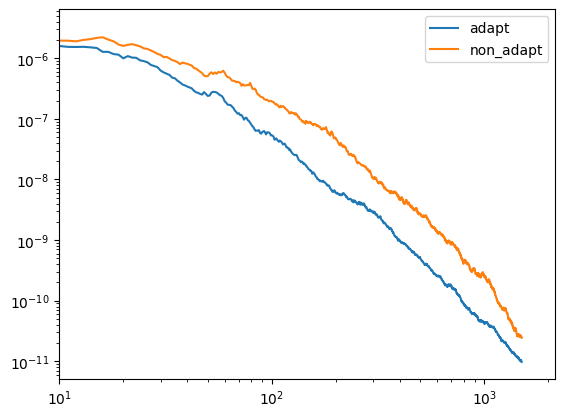

In [123]:


evol_det_times_adaptive = jax.vmap(lambda a: jax.vmap(lambda a: jnp.linalg.det(a))(a))(results_adaptive[1][0]).mean(
    axis=0)
evol_det_times_adaptive_std = jnp.std(
    jax.vmap(lambda a: jax.vmap(lambda a: jnp.linalg.det(a))(a))(results_adaptive[1][0]), axis=0)

evol_det_times_non_adaptive = jax.vmap(lambda a: jax.vmap(lambda a: jnp.linalg.det(a))(a))(
    results_non_adaptive[1][0]).mean(axis=0)
evol_det_times_non_adaptive_std = jnp.std(
    jax.vmap(lambda a: jax.vmap(lambda a: jnp.linalg.det(a))(a))(results_non_adaptive[1][0]), axis=0)

plt.plot(evol_det_times_adaptive,
         label='adapt')
plt.plot(evol_det_times_non_adaptive,
         label='non_adapt')
plt.loglog()
plt.xlim(1e1)
plt.legend()
plt.show()

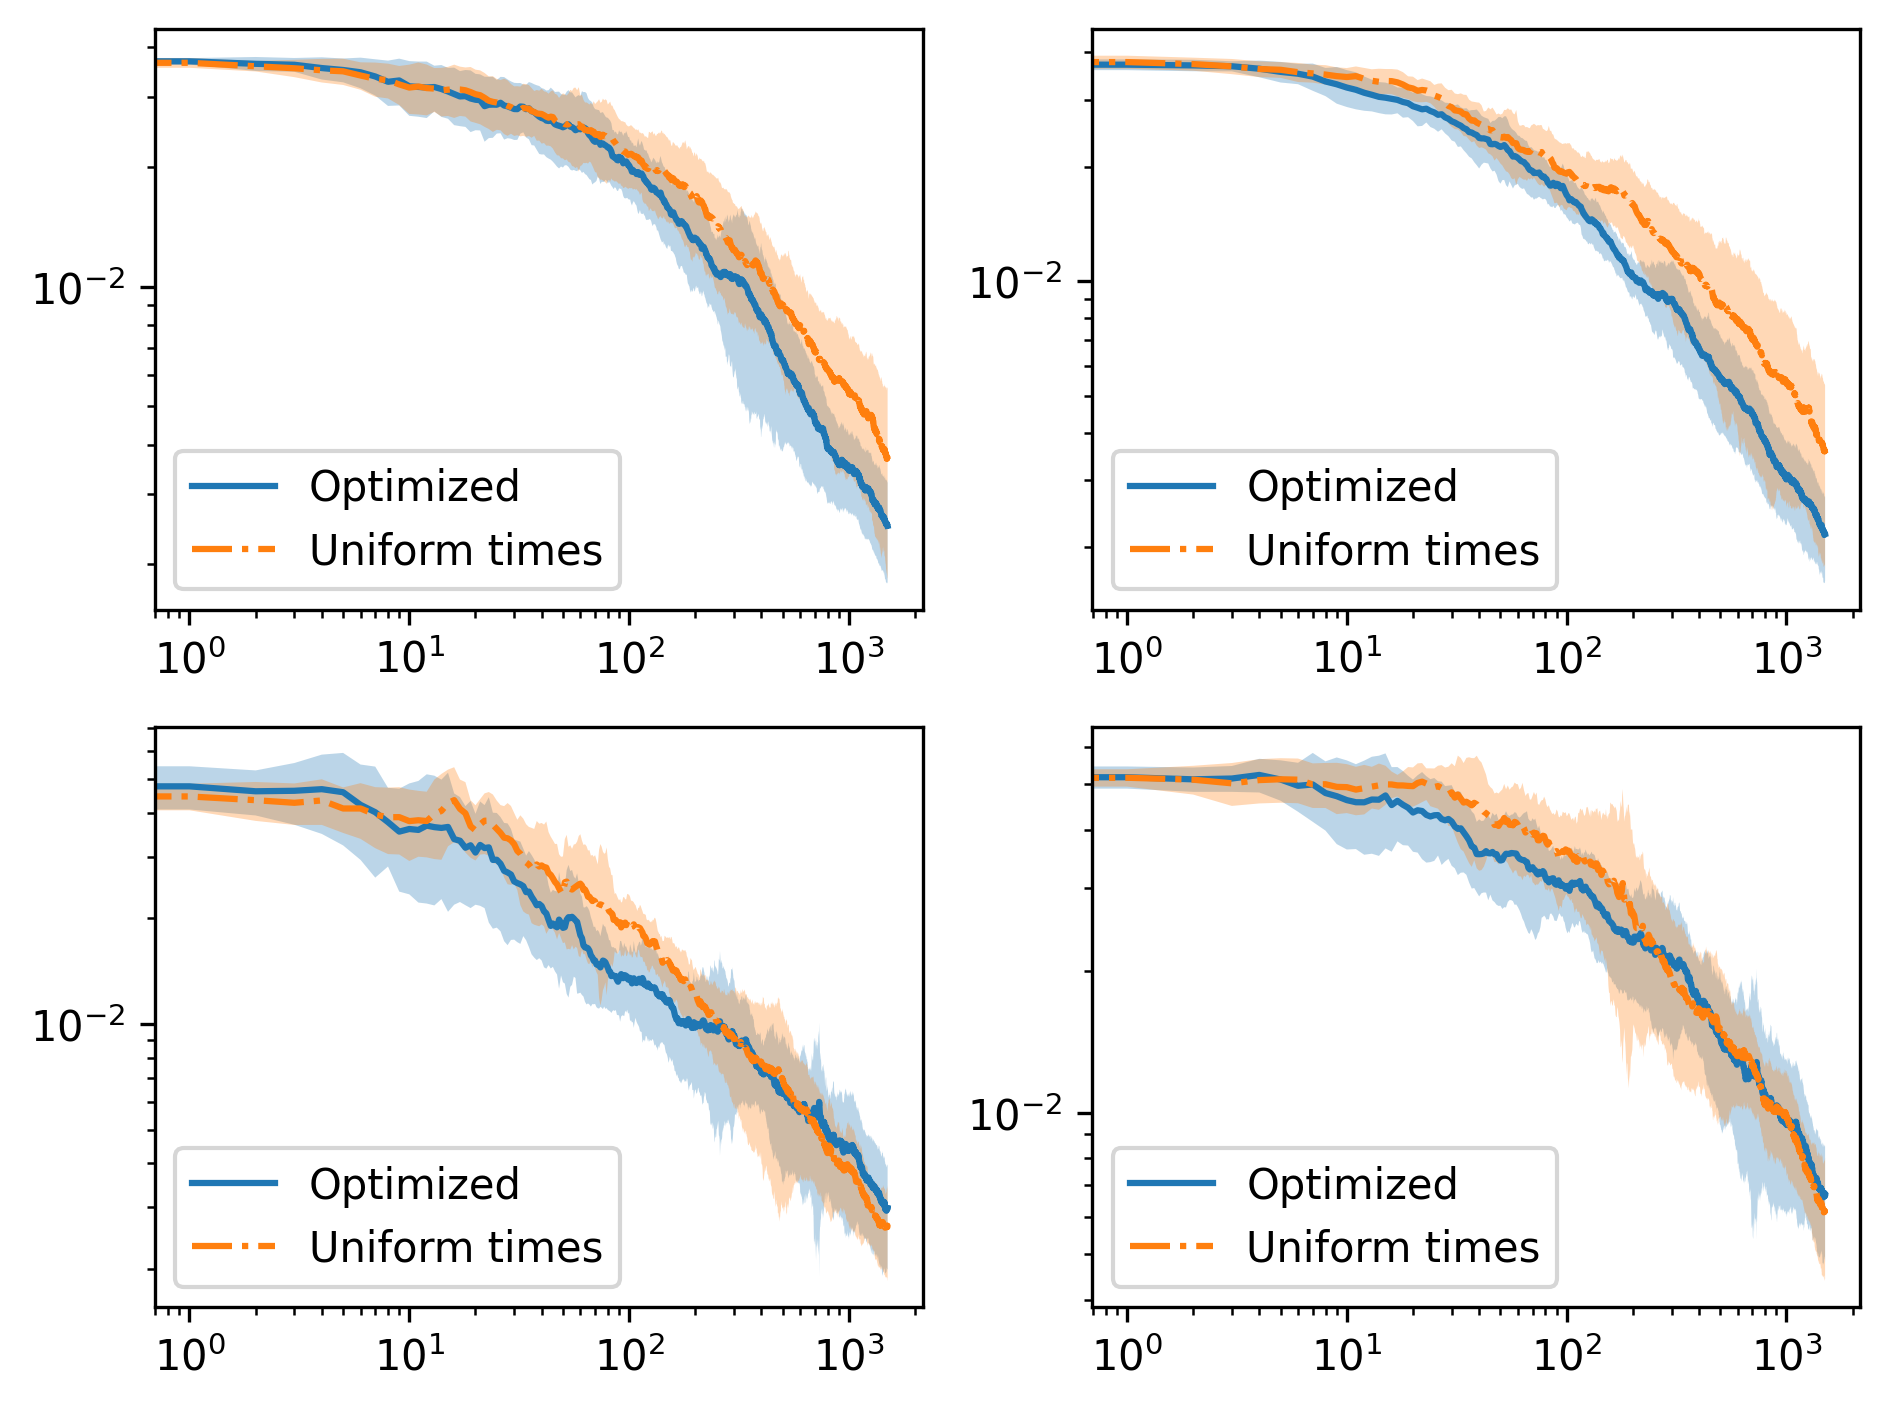

In [124]:
fig, axs = plt.subplots(2, 2, dpi=300)
x = jnp.arange(max_iteration)
for i, ax in enumerate(axs.flatten()):
    ax.plot(x, jnp.mean(results_adaptive[1][0], axis=0)[:, i, i], '-', label='Optimized')

    ax.fill_between(x=x,
                    y1=jnp.mean(results_adaptive[1][0], axis=0)[:, i, i] - jnp.nanstd(results_adaptive[1][0], axis=0)[:,
                                                                           i,
                                                                           i],
                    y2=jnp.mean(results_adaptive[1][0], axis=0)[:, i, i] + jnp.nanstd(results_adaptive[1][0], axis=0)[:,
                                                                           i,
                                                                           i], alpha=0.3)

    ax.plot(x, jnp.mean(results_non_adaptive[1][0], axis=0)[:, i, i], '-.', label="Uniform times")
    # 
    ax.fill_between(x=x,
                    y1=jnp.mean(results_non_adaptive[1][0], axis=0)[:, i, i] - jnp.nanstd(results_non_adaptive[1][0],
                                                                                          axis=0)[
                                                                               :, i, i],
                    y2=jnp.mean(results_non_adaptive[1][0], axis=0)[:, i, i] + jnp.nanstd(results_non_adaptive[1][0],
                                                                                          axis=0)[
                                                                               :, i, i], alpha=0.3)
    ax.loglog()
    ax.legend()

plt.tight_layout()
plt.show()

In [125]:
print(jnp.median(jax.vmap(lambda a, b: est_par(a, b), in_axes=(0, 0))(results_adaptive[0][1], results_adaptive[0][2]),
                 axis=0))
print(jnp.median(
    jax.vmap(lambda a, b: est_par(a, b), in_axes=(0, 0))(results_non_adaptive[0][1], results_non_adaptive[0][2]),
    axis=0))

print(true_parameters)

[ 0.3119291   0.36892313  0.08772971 -0.28470516]
[ 0.32991427  0.41641062  0.07760927 -0.32120973]
[ 0.3142169   0.35833007  0.05385149 -0.33369482]


In [128]:
# plt.hist(np.array(results_adaptive[1][1]).flatten(), bins=200)
# plt.show()

In [129]:
# plt.hist(np.array(results_non_adaptive[1][1]).flatten(), bins=200)
# plt.show()

In [130]:
results_adaptive[0][2].shape

(10, 1000)

In [131]:
jnp.mean(jax.vmap(lambda p, w: est_par(p, w), in_axes=(0, 0))(results_adaptive[0][1], results_adaptive[0][2]), axis=0)

Array([ 0.32110813,  0.37081   ,  0.07400094, -0.312111  ], dtype=float32)

In [132]:
results_adaptive[0][1].shape

(10, 1000, 4)

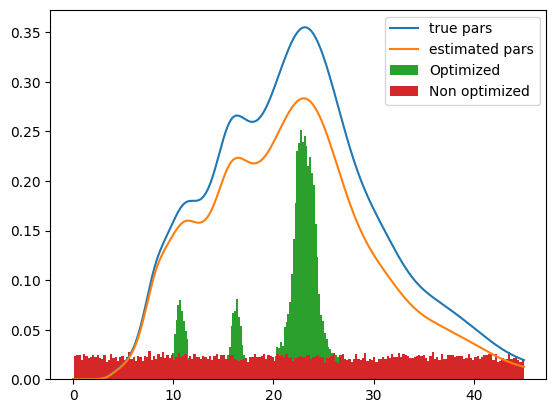

In [133]:
times = jnp.linspace(0, 45, 1000)

new_detfimtimes = jax.vmap(
    lambda t: jnp.linalg.det(m.fim(true_parameters, t, dist_initial_state, dist_measurement_basis)))(times)

est_particle_adaptive = jnp.mean(
    jax.vmap(lambda p, w: est_par(p, w), in_axes=(0, 0))(results_adaptive[0][1], results_adaptive[0][2]), axis=0)

est_detfimtimes = jax.vmap(
    lambda t: jnp.linalg.det(m.fim(est_particle_adaptive, t, dist_initial_state, dist_measurement_basis)))(times)

# plt.plot(times, detfimtimes, label="unoptimized")

plt.plot(times, new_detfimtimes * 7, label='true pars')
plt.plot(times, est_detfimtimes * 7, label='estimated pars')

plt.hist(np.array(results_adaptive[1][1]).flatten(), bins=200, density=True, label="Optimized")
plt.hist(np.array(results_non_adaptive[1][1]).flatten(), bins=200, density=True, label="Non optimized")

plt.legend()

# Cacharreo with Solver



In [80]:
plt.hist?

In [ ]:
from jaxopt import ProjectedGradient
from jaxopt.projection import projection_simplex

In [ ]:
loss_f_initial_state = lambda p_state, p_basis: -1 * jnp.linalg.det(
    model.fim(dist_initial_state=p_state, dist_measurement_basis=p_basis, **kwargs))
loss_f_measurement_basis = lambda p_basis, p_state: -1 * jnp.linalg.det(
    model.fim(dist_initial_state=p_state, dist_measurement_basis=p_basis, **kwargs))

pg1 = ProjectedGradient(fun=loss_f_initial_state, projection=projection_simplex, verbose=True, stepsize=0.2)

pg2 = ProjectedGradient(fun=loss_f_measurement_basis, projection=projection_simplex, verbose=True, stepsize=0.2)

pg1_init_state = pg1.init_state(dist_initial_state, dist_measurement_basis)

pg2_init_state = pg1.init_state(dist_measurement_basis, dist_initial_state)

new_pars1 = dist_initial_state
new_pars2 = dist_measurement_basis

new_state1 = pg1_init_state
new_state2 = pg2_init_state

new_pars1, new_state1 = pg1.update(new_pars1, state=new_state1, m=m, particle=true_parameters, t=t,
                                   dist_measurements=new_pars2)

new_pars2, new_state2 = pg2.update(new_pars2, state=new_state2, m=m, particle=true_parameters, t=t,
                                   dist_initial_state=new_pars1)






In [ ]:
# the function to miminize should be the minus determinant with


def loss_f_initial_state(dist_initial_state, m, particle, t, dist_measurements):
    fim = m.fim(particle, t, dist_initial_state, dist_measurements)
    return -jnp.linalg.det(fim)
    # return -jnp.trace(fim)


def loss_f_measurement_basis(dist_measurements, m, particle, t, dist_initial_state):
    fim = m.fim(particle, t, dist_initial_state, dist_measurements)
    return -jnp.linalg.det(fim)
    # return -jnp.trace(fim)


In [ ]:
pg1 = ProjectedGradient(fun=loss_f_initial_state, projection=projection_simplex, verbose=True, stepsize=0.2)

pg2 = ProjectedGradient(fun=loss_f_measurement_basis, projection=projection_simplex, verbose=True, stepsize=0.2)


# pg_init_state = pg1.init_state(dist_initial_state, m=m, particle=true_parameters, t=t, dist_measurements=dist_measurement_basis)
# new_params = dist_initial_state
# new_state = pg_init_state

In [ ]:
pg1_init_state = pg1.init_state(dist_initial_state, m=m, particle=true_parameters, t=t,
                                dist_measurements=dist_measurement_basis)

pg2_init_state = pg1.init_state(dist_measurement_basis, m=m, particle=true_parameters, t=t,
                                dist_initial_state=dist_initial_state)

new_pars1 = dist_initial_state
new_pars2 = dist_measurement_basis

new_state1 = pg1_init_state
new_state2 = pg2_init_state

In [ ]:
new_pars1, new_state1 = pg1.update(new_pars1, state=new_state1, m=m, particle=true_parameters, t=t,
                                   dist_measurements=new_pars2)

new_pars2, new_state2 = pg2.update(new_pars2, state=new_state2, m=m, particle=true_parameters, t=t,
                                   dist_initial_state=new_pars1)

print(new_pars1)
print(new_pars2)

aux = m.fim(true_parameters, t, new_pars1, new_pars2)
print(aux)
print(jnp.linalg.det(aux))

In [ ]:
jnp.linalg.eigh(aux)[0]

In [ ]:
jnp.linalg.eigh(m.fim(true_parameters, t, dist_initial_state, dist_measurement_basis))[0]

In [ ]:
# pg.run(dist_initial_state, m=m, particle=true_parameters, t=t, dist_measurements=dist_measurement_basis)

In [ ]:


times = jnp.linspace(0, 50, 1000)

detfimtimes = jax.vmap(lambda t: jnp.linalg.det(m.fim(true_parameters, t, dist_initial_state, dist_measurement_basis)))(
    times)

new_detfimtimes = jax.vmap(
    lambda t: jnp.linalg.det(m.fim(true_parameters, t, new_pars1, new_pars2)))(times)

plt.plot(times, detfimtimes, label="unoptimized")
plt.plot(times, new_detfimtimes, label='optimized')
plt.legend()
